(using_logistic5)=
# Using Logistic-5


We use the same dataset from {ref}`getting_started` with a five parameter logistic-5 function.


In [1]:
from util import plot

/home/vishu/repos/hbmep/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
import os

import pandas as pd
import hbmep as mep

url = "https://raw.githubusercontent.com/hbmep/hbmep/refs/heads/docs-data/data/mock_data.csv"
df = pd.read_csv(url)


## Build the model

In [3]:
model = mep.StandardHB()

# Point to the respective columns in dataframe
model.intensity = "TMSIntensity"
model.features = ["participant"]
model.response = ["PKPK_ECR", "PKPK_FCR"]

# Set the function
model._model = model.logistic5


## Running the model

In [4]:
# Process the dataframe
df, encoder = model.load(df)

# Run
mcmc, posterior = model.run(df=df)

# Check convergence diagnostics
summary_df = model.summary(posterior)
print(summary_df.to_string())


2026-04-19 00:21:41,507 - hbmep.util.util - INFO - func:load took: 0.00 sec


2026-04-19 00:21:42,594 - hbmep.util.util - INFO - func:trace took: 1.09 sec
2026-04-19 00:21:42,595 - hbmep.model.base_model - INFO - Running...
Compiling.. :   0%|          | 0/3000 [00:00<?, ?it/s]





Running chain 0:   0%|          | 0/3000 [00:01<?, ?it/s]





Running chain 0:   5%|▌         | 150/3000 [00:05<01:08, 41.84it/s]


Running chain 0:  10%|█         | 300/3000 [00:06<00:36, 73.39it/s]

Running chain 0:  15%|█▌        | 450/3000 [00:07<00:25, 100.90it/s]


Running chain 0:  20%|██        | 600/3000 [00:08<00:19, 120.67it/s]


Running chain 0:  25%|██▌       | 750/3000 [00:08<00:16, 140.45it/s]


Running chain 0:  30%|███       | 900/3000 [00:09<00:14, 146.47it/s]


Running chain 0:  35%|███▌      | 1050/3000 [00:10<00:12, 154.52it/s]


Running chain 0:  45%|████▌     | 1350/3000 [00:12<00:08, 188.02it/s]


Running chain 0:  50%|█████     | 1500/3000 [00:12<00:07, 201.49it/s]



Running chain 0:  55%|█████▌    | 1650/3000 [00:13<00:06, 205.21it/s]

Running chain 0:  60

                mean     sd  hdi_2.5%  hdi_97.5%  mcse_mean  mcse_sd  ess_bulk  ess_tail  r_hat
a_loc         42.051  6.281    29.646     55.300      0.138    0.269    2864.0    1277.0    1.0
a_scale       13.068  7.704     4.772     28.420      0.211    0.428    2332.0    1758.0    1.0
b_scale        0.597  0.347     0.173      1.249      0.011    0.017    1228.0    1332.0    1.0
g_scale        0.012  0.005     0.006      0.023      0.000    0.000     948.0     776.0    1.0
h_scale        0.225  0.099     0.098      0.407      0.004    0.007     975.0    1047.0    1.0
v_scale        0.174  0.188     0.000      0.525      0.003    0.008    3709.0    2134.0    1.0
c₁_scale       2.922  2.658     0.047      8.296      0.048    0.047    2497.0    2860.0    1.0
c₂_scale       0.284  0.106     0.131      0.504      0.003    0.003    1187.0    1685.0    1.0
a[0, 0]       35.709  0.736    34.354     37.190      0.011    0.012    4527.0    2823.0    1.0
a[0, 1]       34.102  0.714    32.984   

## Visualizing the curves

In [5]:
# Create prediction dataframe
prediction_df = model.make_prediction_dataset(df=df, num_points=1000)

# Use the model to predict on the prediction dataframe
predictive = model.predict(df=prediction_df, posterior=posterior)

# Create the output directory
current_dir = os.getcwd()
output_dir = os.path.join(current_dir, "hbmep-using-logistic5")
os.makedirs(output_dir, exist_ok=True)

# Plot estimated curves
output_path = os.path.join(output_dir, "curves.pdf")
model.plot_curves(
    df=df,
    prediction_df=prediction_df,
    predictive=predictive,
    posterior=posterior,
    encoder=encoder,
    output_path=output_path
)


2026-04-19 00:22:04,499 - hbmep.util.util - INFO - func:make_prediction_dataset took: 0.07 sec
2026-04-19 00:22:17,063 - hbmep.util.util - INFO - func:predict took: 12.56 sec
2026-04-19 00:22:17,063 - hbmep.model.base_model - INFO - Plotting curves...
2026-04-19 00:22:17,063 - hbmep.model.base_model - INFO - /home/vishu/repos/hbmep/docs/source/tutorials/hbmep-using-logistic5/curves.pdf
2026-04-19 00:22:18,071 - hbmep.plotter - INFO - Page 1 of 1 done.
2026-04-19 00:22:18,072 - hbmep.util.util - INFO - Saving pdf...
2026-04-19 00:22:18,495 - hbmep.util.util - INFO - Saved to /home/vishu/repos/hbmep/docs/source/tutorials/hbmep-using-logistic5/curves.pdf
2026-04-19 00:22:18,496 - hbmep.util.util - INFO - func:plot_curves took: 1.43 sec


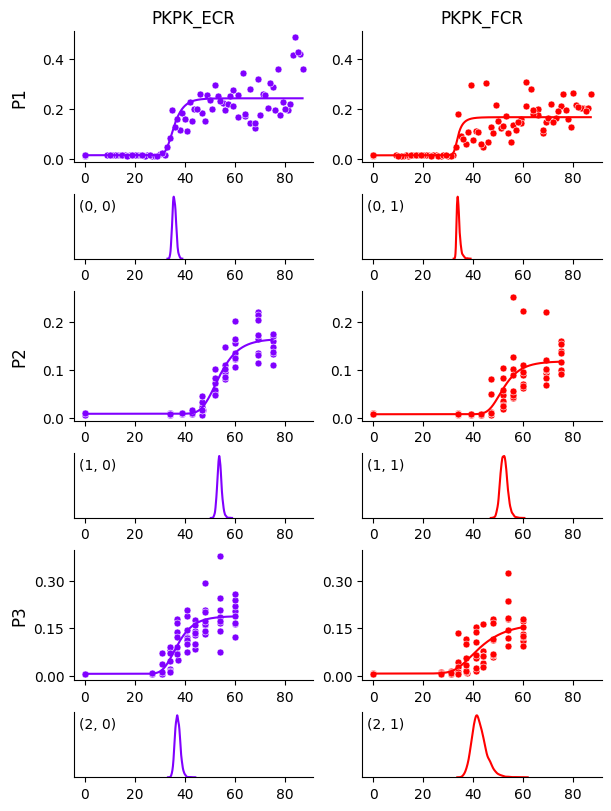

In [6]:
plot(
    df=df,
    **model.variables,
    encoder=encoder,
    posterior=posterior,
    prediction_df=prediction_df,
    predictive=predictive,
    predictive_hdi_prob=0.95,
)


We see that the curve for participant P1 and muscle FCR is no longer biased by those few data points, compared to {ref}`getting_started`. This becomes even clearer when we plot the HDIs around the curves below.


In [7]:
# Plot observations HDI
output_path = os.path.join(output_dir, "obs_hdi.pdf")
model.plot_curves(
    df=df,
    prediction_df=prediction_df,
    predictive=predictive,
    posterior=posterior,
    encoder=encoder,
    output_path="mixture_obs_hdi.pdf",
    predictive_hdi_var=mep.site.obs,
    predictive_hdi_prob=0.95
)

2026-04-19 00:22:19,540 - hbmep.model.base_model - INFO - Plotting curves...
2026-04-19 00:22:19,540 - hbmep.model.base_model - INFO - mixture_obs_hdi.pdf
2026-04-19 00:22:21,268 - hbmep.plotter - INFO - Page 1 of 1 done.
2026-04-19 00:22:21,272 - hbmep.util.util - INFO - Saving pdf...
2026-04-19 00:22:21,715 - hbmep.util.util - INFO - Saved to mixture_obs_hdi.pdf
2026-04-19 00:22:21,715 - hbmep.util.util - INFO - func:plot_curves took: 2.18 sec


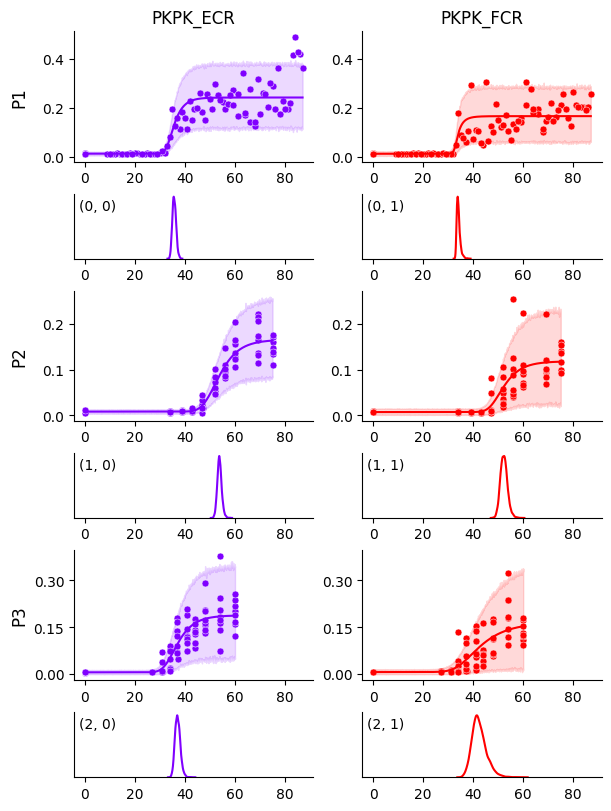

In [8]:
plot(
    df=df,
    **model.variables,
    encoder=encoder,
    posterior=posterior,
    prediction_df=prediction_df,
    predictive=predictive,
    predictive_hdi_var=mep.site.obs,
    predictive_hdi_prob=0.95,
)


## Accessing parameters

In this model, the parameter `a` corresponds to the $S_{50}$ and can be accessed as below.


In [9]:
# S50 parameter
a = posterior[mep.site.a]
print(a.shape)


(4000, 3, 2)
